In [11]:
import numpy as np
import math
from scipy.linalg import polar
from scipy.linalg import svd
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sqlite3
import os

In [ ]:
def generateAffineMatrix3D(matrix_affineA, matrix_affineAdash):
    # 各行列から平行移動を含む点を抽出
    points_A = np.array([mat[:3, 3] for mat in matrix_affineA])  # Aの各点 (x, y, z)
    points_Adash = np.array([mat[:3, 3] for mat in matrix_affineAdash])  # Adashの各点 (x', y', z')
    
    # アフィン変換行列を求めるための最小二乗法
    ones = np.ones((points_A.shape[0], 1))  # 点数分の1列
    P = np.hstack((points_A, ones))  # Aの点を拡張 [x, y, z, 1]
    print(P)
    Q = points_Adash  # Adashの点
    print(Q)
    
    # 最小二乗法で解を求める
    affine_matrix, _, _, _ = np.linalg.lstsq(P, Q, rcond=None)
    print("affine_matrix")
    print(affine_matrix)

    # 4x4のアフィン変換行列を構築
    affine_matrix_4x4 = np.eye(4)
    affine_matrix_4x4[:3, :] = affine_matrix.T
    
    return affine_matrix_4x4

def generateAffineMatrix3DSelf(matrix_affineA, matrix_affineAdash):
    # Aの点を拡張 [x, y, z, 1]
    points_A = np.array([mat[:3, 3] for mat in matrix_affineA])
    points_Adash = np.array([mat[:3, 3] for mat in matrix_affineAdash]) 
    
    # P = points_A
    P = np.hstack((points_A, np.ones((points_A.shape[0], 1))))
    # P = np.vstack((P, np.array([1, 1, 1, 1])))
    # print(P)
    Q = points_Adash
    # Q = np.hstack((points_Adash, np.ones((points_Adash.shape[0], 1))))
    # Q = np.vstack((Q, np.array([1, 1, 1, 1])))

    # print(Q)
    
    # 最小二乗法で解を求める
    affine_matrix = leastSquaresMethod(P, Q)
    
    # 4x4のアフィン変換行列を構築
    affine_matrix = np.vstack((affine_matrix.T, np.array([0, 0, 0, 1])))
    
    return affine_matrix

def generateAffineMatrix3DSelfLU(matrix_affineA, matrix_affineAdash):
    """LU分解を用いた最小二乗法でアフィン変換行列を求める"""
    points_A = np.array([mat[:3, 3] for mat in matrix_affineA])
    points_Adash = np.array([mat[:3, 3] for mat in matrix_affineAdash]) 
    
    # 拡張行列を作成
    P = np.hstack((points_A, np.ones((points_A.shape[0], 1))))
    # print(P)
    Q = points_Adash
    # print(Q)

    # 最小二乗法で解を求める
    affine_matrix = leastSquaresMethodLU(P, Q)

    print("affine_matrix")
    print(affine_matrix)

    # 4x4のアフィン変換行列を構築
    affine_matrix = np.vstack((affine_matrix.T, np.array([0, 0, 0, 1])))

    return affine_matrix

def LU(A: np.array) -> np.array:
    """LU分解"""
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            U[i, j] = A[i, j] - np.sum(L[i, :i] * U[:i, j])
        # print("U")
        # print(U)
        for j in range(i + 1, n):
            L[j, i] = (A[j, i] - np.sum(L[j, :i] * U[:i, i])) / U[i, i]
        # print("L")
        # print(L)

    return L, U

def eq_solve(P: np.array, Q: np.array) -> np.array:
    # LU分解
    L, U = LU(P)
    # print("L")
    # print(L)
    # print("U")
    # print(U)
    n, m = Q.shape  # Q の形状を取得
    y = np.zeros((n, m))  # 前進代入の解ベクトル y を用意

    # 前進代入
    for i in range(n):
        # print("Q[i][k],dot",i)
        # print(Q[i, :],np.dot(L[i, :i], y[:i, :]))
        y[i, :] = Q[i, :] - np.dot(L[i, :i], y[:i, :])

    # print("y")
    # print(y)

    x = np.zeros((n, m))  # 解ベクトル x を用意

    # 後退代入
    for i in range(n - 1, -1, -1):
        if np.abs(U[i, i]) < 1e-8:  # 0除算防止
            # print(f"Warning: U[{i}, {i}] is nearly zero. Adding small value.")
            U[i, i] = 1e-8
        # print(f"np.dot({U[i, i+1:]}, {x[i+1:, :]})")
        # print(y[i, :],"\n",np.dot(U[i, i+1:], x[i+1:, :]),"\n",U[i, i])
        x[i, :] = (y[i, :] - np.dot(U[i, i+1:], x[i+1:, :])) / U[i, i]
        # print(f"x {i}")
        # print(x)

    # print("x")
    # print(x)
    return x

def leastSquaresMethod(P: np.array, Q: np.array) -> np.array:
    # 最小二乗法と逆行列を用いた解法
    affine_matrix = np.linalg.inv(P.T @ P) @ P.T @ Q
    return affine_matrix

def leastSquaresMethodLU(P: np.array, Q: np.array) -> np.array:
    # 最小二乗法で解を求める
    affine_matrix = eq_solve(P.T @ P, P.T) @ Q
    # print("eq_solve(P.T @ P, P.T)")
    # print(eq_solve(P.T @ P, P.T))
    # print("Q")
    # print(Q)
    return affine_matrix

def leastSquaresMethod(P: np.array, Q: np.array) -> np.array:
    # 最小二乗法で解を求める
    affine_matrix = np.linalg.solve(P.T @ P, P.T) @ Q
    return affine_matrix


def decompose_affine_matrix(matrix: np.ndarray) -> np.ndarray:
    """
    アフィン変換行列からスケーリング成分と回転行列を分離して抽出する。

    Parameters:
        matrix (np.ndarray): 4x4 アフィン変換行列

    Returns:
        scale: np.ndarray - x, y, z のスケーリング成分
        rotation: np.ndarray - 3x3 の回転行列
    """
    if matrix.shape != (4, 4):
        raise ValueError("Input matrix must be a 4x4 numpy array.")

    # 3x3 部分行列（回転 + スケーリング）
    M = matrix[:3, :3]

    # 極分解（M = R × S）
    R, S = polar(M)

    a = np.asarray(M)
    if a.ndim != 2:
        raise ValueError("`a` must be a 2-D array.")

    w, s, vh = svd(a, full_matrices=False)
    # print("w")
    # print(w)
    # print("s")
    # print(s)
    # print("vh")
    # print(vh)
    R = w.dot(vh)
    # print("R")
    # print(w @ vh)
    # S = (vh.T.conj() * s).dot(vh)
    # print("R")
    # print(R)

    # スケーリング成分は S の対角要素の平方根（または M 各軸ベクトルのノルムでもOK）
    scale_x = np.linalg.norm(M[:, 0])
    scale_y = np.linalg.norm(M[:, 1])
    scale_z = np.linalg.norm(M[:, 2])
    scale = np.array([scale_x, scale_y, scale_z])
    # print("scale")
    # print(scale)

    # 回転行列を置き換えたアフィン行列を構築
    rotation = R
    affine_matrix = np.eye(4)
    affine_matrix[:3, :3] = rotation
    affine_matrix[:3, 3] = matrix[:3, 3]  # 平行移動成分を保持
    # print("affine_matrix")
    print(affine_matrix)
    return affine_matrix


In [ ]:
# ワールドから2つの座標系を作成
hash1 = "323"
hash2 = "525"
hash3 = "433"
hash4 = "123"

hashMax = 50
hashMin = 0

# 全ての組み合わせを生成
"""
hash値は `{0~50}{0~50}{0~50}` で生成されます
それらのhash値が重複しない様に、4つ選びます
その4つは順序を考慮してください
"""
def generate_hashes(hashMin, hashMax) -> pd.DataFrame:
    hashes = [f"{i:03}{j:03}{k:03}" for i in range(hashMin, hashMax + 1) for j in range(hashMin, hashMax + 1) for k in range(hashMin, hashMax + 1)]
    # 重複しない4つのhash値を選ぶ
    hash_df = pd.DataFrame(columns=['hash_a', 'hash_b', 'hash_c', 'hash_d'])
    for i in range(len(hashes)):
        for j in range(i + 1, len(hashes)):
            for k in range(j + 1, len(hashes)):
                for l in range(k + 1, len(hashes)):
                    hash_df = pd.concat([hash_df, pd.DataFrame([[hashes[i], hashes[j], hashes[k], hashes[l]]], columns=['hash_a', 'hash_b', 'hash_c', 'hash_d'])], ignore_index=True)
    return hash_df

# それぞれ a,b,c ・ a,b,d ・ a,d,c ・ b,d,c のベクトルを計算しhash_dfに保存
def calculate_vectors(hash_df) -> pd.DataFrame:
    # データベースに接続
    conn = sqlite3.connect("world.db")
    c = conn.cursor()

    vectors = []
    for index, row in hash_df.iterrows():
        hash_a = row['hash_a']
        hash_b = row['hash_b']
        hash_c = row['hash_c']
        hash_d = row['hash_d']

        # 各hashに対応する行列を取得
        c.execute("SELECT * FROM world WHERE hash=?", (hash_a,))
        rows_a = c.fetchall()
        rows_a = [list(row) for row in rows_a]

        c.execute("SELECT * FROM world WHERE hash=?", (hash_b,))
        rows_b = c.fetchall()
        rows_b = [list(row) for row in rows_b]

        c.execute("SELECT * FROM world WHERE hash=?", (hash_c,))
        rows_c = c.fetchall()
        rows_c = [list(row) for row in rows_c]

        c.execute("SELECT * FROM world WHERE hash=?", (hash_d,))
        rows_d = c.fetchall()
        rows_d = [list(row) for row in rows_d]

        # ベクトルを計算
        vector_ab = np.array(rows_b[0][0:3]) - np.array(rows_a[0][0:3])
        vector_ac = np.array(rows_c[0][0:3]) - np.array(rows_a[0][0:3])
        vector_ad = np.array(rows_d[0][0:3]) - np.array(rows_a[0][0:3])
        vector_bc = np.array(rows_c[0][0:3]) - np.array(rows_b[0][0:3])
        vector_bd = np.array(rows_d[0][0:3]) - np.array(rows_b[0][0:3])
        # vector_cd = np.array(rows_d[0][0:2]) - np.array(rows_c[0][0:2])

        vector_abc = vector_ab + vector_ac
        vector_abd = vector_ab + vector_ad
        vector_acd = vector_ac + vector_ad
        vector_bcd = vector_bc + vector_bd

        # print(f"hash_a: {hash_a}, hash_b: {hash_b}, hash_c: {hash_c}, hash_d: {hash_d}")
        # print(f"vector_ab: {vector_ab}, vector_ac: {vector_ac}, vector_ad: {vector_ad}, vector_bc: {vector_bc}, vector_bd: {vector_bd}")
        # print(f"vector_abc: {vector_abc}, vector_abd: {vector_abd}, vector_acd: {vector_acd}, vector_bcd: {vector_bcd}")

        vectors.append({
            'vector_abc': vector_abc,
            'vector_abd': vector_abd,
            'vector_acd': vector_acd,
            'vector_bcd': vector_bcd
        })

        # break
    
    conn.close()

    hash_df = pd.concat([hash_df, pd.DataFrame(vectors)], axis=1)
    return hash_df

# アフィン行列の生成を行い、hash値から、実際にどの程度計算に誤差があったのかをdfに保存
def generate_affine_matrices(hash_df) -> pd.DataFrame:
    # データベースに接続
    conn = sqlite3.connect("world.db")
    c = conn.cursor()

    errors = []
    affine_matrices = []
    for index, row in hash_df.iterrows():
        hash_a = row['hash_a']
        hash_b = row['hash_b']
        hash_c = row['hash_c']
        hash_d = row['hash_d']

        c.execute("SELECT * FROM world WHERE hash = ?", (hash_a,))
        rows1 = c.fetchall()
        rows1 = [list(row) for row in rows1 ]

        # ワールドの座標系2のアフィン変換行列を取得
        c.execute("SELECT * FROM world WHERE hash = ?", (hash_b,))
        rows2 = c.fetchall()
        rows2 = [list(row) for row in rows2]

        # ワールドの座標系3のアフィン変換行列を取得
        c.execute("SELECT * FROM world WHERE hash = ?", (hash_c,))
        rows3 = c.fetchall()
        rows3 = [list(row) for row in rows3]

        # ワールドの座標系4のアフィン変換行列を取得
        c.execute("SELECT * FROM world WHERE hash = ?", (hash_d,))
        rows4 = c.fetchall()
        rows4 = [list(row) for row in rows4]

        # 各行列をnumpy配列に変換
        matrix_affine1 = np.array([
            [[1, 0, 0, rows1[0][4]],[0, 1, 0, rows1[0][5]],[0, 0, 1, rows1[0][6]],[0, 0, 0, 1]],
            [[1, 0, 0, rows2[0][4]],[0, 1, 0, rows2[0][5]],[0, 0, 1, rows2[0][6]],[0, 0, 0, 1]],
            [[1, 0, 0, rows3[0][4]],[0, 1, 0, rows3[0][5]],[0, 0, 1, rows3[0][6]],[0, 0, 0, 1]],
            [[1, 0, 0, rows4[0][4]],[0, 1, 0, rows4[0][5]],[0, 0, 1, rows4[0][6]],[0, 0, 0, 1]]
        ])

        matrix_affine2 = np.array([
            [[1, 0, 0, rows1[0][4]],[0, 1, 0, rows1[0][5]],[0, 0, 1, rows1[0][6]],[0, 0, 0, 1]],
            [[1, 0, 0, rows2[0][4]],[0, 1, 0, rows2[0][5]],[0, 0, 1, rows2[0][6]],[0, 0, 0, 1]],
            [[1, 0, 0, rows3[0][4]],[0, 1, 0, rows3[0][5]],[0, 0, 1, rows3[0][6]],[0, 0, 0, 1]],
            [[1, 0, 0, rows4[0][4]],[0, 1, 0, rows4[0][5]],[0, 0, 1, rows4[0][6]],[0, 0, 0, 1]]
        ])

        # アフィン変換行列を生成
        affine_matrix = generateAffineMatrix3DSelfLU(matrix_affine1, matrix_affine2)
        affine_matrix = decompose_affine_matrix(affine_matrix)

        # アフィン行列を保存
        affine_matrices.append(affine_matrix)

        # 誤差の計算
        errors.append(calculate_error(rows1, affine_matrix))
    
    conn.close()

    # 誤差をhash_dfに追加
    hash_df['error_x'] = [error[0] for error in errors]
    hash_df['error_y'] = [error[1] for error in errors]
    hash_df['error_z'] = [error[2] for error in errors]
    
    # アフィン行列をパースして保存
    hash_df['affine_matrix'] = [affine.tolist() for affine in affine_matrices]

    return hash_df

def calculate_error(rows, affine_matrix):
    """
    アフィン変換行列の誤差を計算する。
    """
    matrix = np.array([
        rows[0][4],
        rows[0][5],
        rows[0][6],
        1
    ])

    transformed_matrix = affine_matrix @ matrix
    errors = [
        transformed_matrix[0] - rows[0][4],
        transformed_matrix[1] - rows[0][5],
        transformed_matrix[2] - rows[0][6]
    ]
    return errors

def main():
    # データベースの存在確認
    if not os.path.exists("world.db"):
        print("Database 'world.db' does not exist. Please create it first.")
        return

    # ハッシュ値の生成
    # hashes.dbからhash値を取得
    hash_df = pd.read_sql_query("SELECT * FROM hashes", sqlite3.connect("hashes.db"))
    print("read_sql_query")
    print(hash_df.count())

    # ベクトルの計算
    # hash_df = calculate_vectors(hash_df)
    print("calculate_vectors")

    # hash_df.to_csv("hash_vectors.csv", index=False)
    # hash_df = pd.read_csv("hash_vectors.csv")

    # アフィン行列の生成と誤差の計算
    # hash_df = generate_affine_matrices(hash_df)
    # print("generate_affine_matrices")

    # hash_df.to_csv("affine_matrices.csv", index=False)
    hash_df = pd.read_csv("affine_matrices.csv")

    # ['error_norm'] 列を追加
    hash_df['error_norm'] = np.sqrt(hash_df['error_x']**2 + hash_df['error_y']**2 + hash_df['error_z']**2)

    # spllite3のaffine_matricesデータベースに保存
    conn = sqlite3.connect("affine_matrices.db")
    hash_df.to_sql('affine_matrices', conn, if_exists='replace', index=False)
    conn.close()


main()

read_sql_query
id        7920
hash_a    7920
hash_b    7920
hash_c    7920
hash_d    7920
dtype: int64
calculate_vectors


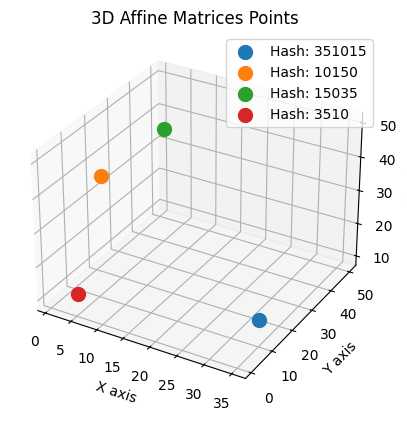

In [83]:
# エラーのノルムが一番小さいもののハッシュ値を取得
def get_best_hash(hash_df):
    best_index = hash_df['error_norm'].idxmin()
    best_hash = hash_df.iloc[best_index]
    return best_hash


hash_df = pd.read_sql_query("SELECT * FROM affine_matrices", sqlite3.connect("affine_matrices.db"))
best_hash = get_best_hash(hash_df)

# 3Dプロットの表示
def plot_3d_affine_matrices(best_hashs):
    conn = sqlite3.connect("world.db")
    c = conn.cursor()
    
    potions = []
    for hash_value in best_hashs:
        c.execute("SELECT * FROM world WHERE hash = ?", (str(hash_value),))
        rows = c.fetchall()
        rows = [list(row) for row in rows]
        potions.append([
            rows[0][0], 
            rows[0][1], 
            rows[0][2]  
        ])
    
    conn.close()

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # 各ポーションの位置をプロット
    for i, potion in enumerate(potions):
        ax.scatter(potion[0], potion[1], potion[2], label=f"Hash: {best_hash[f'hash_{chr(97+i)}']}", s=100)
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    ax.set_title('3D Affine Matrices Points')
    ax.legend([f"Hash: {best_hash['hash_a']}", f"Hash: {best_hash['hash_b']}", f"Hash: {best_hash['hash_c']}", f"Hash: {best_hash['hash_d']}"])
    plt.show()

plot_3d_affine_matrices([
    best_hash['hash_a'],
    best_hash['hash_b'],
    best_hash['hash_c'],
    best_hash['hash_d']
])

In [14]:
# データベースに接続
conn = sqlite3.connect("world.db")
c = conn.cursor()

# CREATE TABLE world (x INTEGER, y INTEGER, z INTEGER, hash TEXT, matrix_1_x REAL, matrix_1_y REAL, matrix_1_z REAL, matrix_2_x REAL, matrix_2_y REAL, matrix_2_z REAL)
# ワールドの座標系1のアフィン変換行列を取得
c.execute("SELECT * FROM world WHERE hash = ?", (hash1,))
rows1 = c.fetchall()
rows1 = [list(row) for row in rows1 ]

# ワールドの座標系2のアフィン変換行列を取得
c.execute("SELECT * FROM world WHERE hash = ?", (hash2,))
rows2 = c.fetchall()
rows2 = [list(row) for row in rows2]

# ワールドの座標系3のアフィン変換行列を取得
c.execute("SELECT * FROM world WHERE hash = ?", (hash3,))
rows3 = c.fetchall()
rows3 = [list(row) for row in rows3]

c.close()

# ワールドの座標系1と座標系2のアフィン変換行列から座標系1と座標系3のアフィン変換行列を求める
matrix_affine1 = np.array([
    [[1, 0, 0, rows1[0][4]],[0, 1, 0, rows1[0][5]],[0, 0, 1, rows1[0][6]],[0, 0, 0, 1]],
    [[1, 0, 0, rows2[0][4]],[0, 1, 0, rows2[0][5]],[0, 0, 1, rows2[0][6]],[0, 0, 0, 1]],
    [[1, 0, 0, rows3[0][4]],[0, 1, 0, rows3[0][5]],[0, 0, 1, rows3[0][6]],[0, 0, 0, 1]],
])

print("matrix_affine1")
# print(matrix_affine1)

matrix_affine2 = np.array([
    [[1, 0, 0, rows1[0][7]],[0, 1, 0, rows1[0][8]],[0, 0, 1, rows1[0][9]],[0, 0, 0, 1]],
    [[1, 0, 0, rows2[0][7]],[0, 1, 0, rows2[0][8]],[0, 0, 1, rows2[0][9]],[0, 0, 0, 1]],
    [[1, 0, 0, rows3[0][7]],[0, 1, 0, rows3[0][8]],[0, 0, 1, rows3[0][9]],[0, 0, 0, 1]],
])

print("matrix_affine2")
print(matrix_affine2)

affine = generateAffineMatrix3D(matrix_affine1, matrix_affine2)
print(affine)
affine_self = generateAffineMatrix3DSelf(matrix_affine1, matrix_affine2)
print(affine_self)
affine_self_LU = generateAffineMatrix3DSelfLU(matrix_affine1, matrix_affine2)
print(affine_self_LU)

matrix_affine1
matrix_affine2
[[[ 1.          0.          0.         22.84613446]
  [ 0.          1.          0.         -4.16020941]
  [ 0.          0.          1.         29.45277012]
  [ 0.          0.          0.          1.        ]]

 [[ 1.          0.          0.         24.32188483]
  [ 0.          1.          0.         -2.88071366]
  [ 0.          0.          1.         31.49850996]
  [ 0.          0.          0.          1.        ]]

 [[ 1.          0.          0.         22.43037133]
  [ 0.          1.          0.         -4.27144213]
  [ 0.          0.          1.         30.79990349]
  [ 0.          0.          0.          1.        ]]]
[[18.07518928  1.05522759 17.29664786  1.        ]
 [20.71414772  1.82651865 17.96073256  1.        ]
 [18.33400833  2.36764981 17.75551669  1.        ]]
[[22.84613446 -4.16020941 29.45277012]
 [24.32188483 -2.88071366 31.49850996]
 [22.43037133 -4.27144213 30.79990349]]
affine_matrix
[[ 0.57060368  0.69443746  0.28734659]
 [-0.69621511  

In [15]:
# hash = "70163de61cd8d40eb0d70587c380b89c16e6620c2cd3862d5fc9a62bd6134e9c"
hash = "223"
# hash = "87cb9455225e82801c55d7f005a4fda7f7080f2a3bfa1f6ee9cb91e91a6d45ca"

In [16]:
conn = sqlite3.connect("world.db")
c = conn.cursor()

c.execute("SELECT * FROM world WHERE hash = ?", (hash,))
rows1 = c.fetchall()
rows1 = [list(row) for row in rows1 ]
print(rows1)

c.close()

matrix = np.array([
    rows1[0][4],
    rows1[0][5],
    rows1[0][6],
    1
])

print(matrix)
print(affine)

affine_times_matrix = np.dot(affine, matrix)

print(affine_times_matrix)
print(rows1[0][7],rows1[0][8],rows1[0][9])

[[2, 2, 3, '223', 17.462816847312443, 0.31602866771894633, 17.576977943844625, 23.063964542428252, -4.809477091651298, 28.724071602379748]]
[17.46281685  0.31602867 17.57697794  1.        ]
[[ 0.57060368 -0.69621511  0.76335965  0.06346733]
 [ 0.69443746  0.11701637 -0.96877629 -0.07919454]
 [ 0.28734659  0.49156773  1.36775071  0.08270782]
 [ 0.          0.          0.          1.        ]]
[23.22534662 -4.94353928 29.29686233  1.        ]
23.063964542428252 -4.809477091651298 28.724071602379748


In [17]:
conn = sqlite3.connect("world.db")
c = conn.cursor()

c.execute("SELECT * FROM world WHERE hash = ?", (hash,))
rows1 = c.fetchall()
rows1 = [list(row) for row in rows1 ]
print(rows1)

c.close()

matrix = np.array([
    rows1[0][4],
    rows1[0][5],
    rows1[0][6],
    1
])

print(matrix)
print(affine_self)

affine_self_times_matrix = np.dot(affine_self, matrix)

print(affine_self_times_matrix)
print(rows1[0][7],rows1[0][8],rows1[0][9])

[[2, 2, 3, '223', 17.462816847312443, 0.31602866771894633, 17.576977943844625, 23.063964542428252, -4.809477091651298, 28.724071602379748]]
[17.46281685  0.31602867 17.57697794  1.        ]
[[ 0.71801682 -0.40031184 -0.16610716 13.16336167]
 [ 0.70383462  0.13587936 -1.02802713  0.75588624]
 [ 0.42045858  0.75876421  0.52845528 11.91172791]
 [ 0.          0.          0.          1.        ]]
[22.655786   -4.97984714 28.78255711  1.        ]
23.063964542428252 -4.809477091651298 28.724071602379748


In [18]:
conn = sqlite3.connect("world.db")
c = conn.cursor()

c.execute("SELECT * FROM world WHERE hash = ?", (hash,))
rows1 = c.fetchall()
rows1 = [list(row) for row in rows1 ]
print(rows1)

c.close()

matrix = np.array([
    rows1[0][4],
    rows1[0][5],
    rows1[0][6],
    1
])

print(matrix)
print(affine_self_LU)

affine_self_LU_times_matrix = np.dot(affine_self_LU, matrix)

print(affine_self_LU_times_matrix)
print(rows1[0][7],rows1[0][8],rows1[0][9])

[[2, 2, 3, '223', 17.462816847312443, 0.31602866771894633, 17.576977943844625, 23.063964542428252, -4.809477091651298, 28.724071602379748]]
[17.46281685  0.31602867 17.57697794  1.        ]
[[ 5.69889482e-01 -6.97648720e-01  7.67862795e-01  2.37173927e-09]
 [ 6.95328628e-01  1.18805222e-01 -9.74395279e-01 -5.02471700e-07]
 [ 2.86415882e-01  4.89699516e-01  1.37361901e+00  1.67601029e-07]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[23.22810607 -4.9469825  29.30045831  1.        ]
23.063964542428252 -4.809477091651298 28.724071602379748


In [19]:
conn = sqlite3.connect("world.db")
c = conn.cursor()

c.execute("SELECT * FROM world WHERE hash = ?", (hash,))
rows1 = c.fetchall()
rows1 = [list(row) for row in rows1 ]
print(rows1)

c.close()

matrix = np.array([
    rows1[0][4],
    rows1[0][5],
    rows1[0][6],
    1
])

swiftFromAffineMatrix = np.array([[0.7391304328518187, 0.2608695671482568, 0.2608695671481893, -4.440892098500626e-08], [-0.34782609274896803, 1.3478260927490293, 0.3478260927489698, -1.3322676295501878e-07], [-0.4347826048339041, 0.4347826048341439, 1.434782604833929, 8.881784197001252e-08], [0.0, 0.0, 0.0, 1.0]])

print(matrix)
print(swiftFromAffineMatrix)

swiftFromAffineMatrix_times_matrix = np.dot(swiftFromAffineMatrix, matrix)

print(swiftFromAffineMatrix_times_matrix)
print(rows1[0][7],rows1[0][8],rows1[0][9])


[[2, 2, 3, '223', 17.462816847312443, 0.31602866771894633, 17.576977943844625, 23.063964542428252, -4.809477091651298, 28.724071602379748]]
[17.46281685  0.31602867 17.57697794  1.        ]
[[ 7.39130433e-01  2.60869567e-01  2.60869567e-01 -4.44089210e-08]
 [-3.47826093e-01  1.34782609e+00  3.47826093e-01 -1.33226763e-07]
 [-4.34782605e-01  4.34782605e-01  1.43478260e+00  8.88178420e-08]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[17.57504022  0.46565976 17.76401706  1.        ]
23.063964542428252 -4.809477091651298 28.724071602379748


In [20]:
print(hash1, hash2, hash3)
print(hash)
# print(affine)
print(affine_times_matrix)
# print(affine_self)
print(affine_self_times_matrix)
# print(affine_self_LU)
print(affine_self_LU_times_matrix)
# print(swiftFromAffineMatrix)
print(swiftFromAffineMatrix_times_matrix)
print(rows1[0][7],rows1[0][8],rows1[0][9])

323 525 433
223
[23.22534662 -4.94353928 29.29686233  1.        ]
[22.655786   -4.97984714 28.78255711  1.        ]
[23.22810607 -4.9469825  29.30045831  1.        ]
[17.57504022  0.46565976 17.76401706  1.        ]
23.063964542428252 -4.809477091651298 28.724071602379748
